In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 742k/742k [00:11<00:00, 63.4kB/s]

Extracting files...
Path to dataset files: C:\Users\dell\.cache\kagglehub\datasets\sulianova\cardiovascular-disease-dataset\versions\1


In [19]:
import os
print(os.listdir(path))

['cardio_train.csv']


In [23]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "cardio_train.csv"), sep=";")

df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [24]:
df.shape

(70000, 13)

In [25]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [26]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.info

<bound method DataFrame.info of           id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  \
0          0  18393       2     168    62.0    110     80            1     1   
1          1  20228       1     156    85.0    140     90            3     1   
2          2  18857       1     165    64.0    130     70            3     1   
3          3  17623       2     169    82.0    150    100            1     1   
4          4  17474       1     156    56.0    100     60            1     1   
...      ...    ...     ...     ...     ...    ...    ...          ...   ...   
69995  99993  19240       2     168    76.0    120     80            1     1   
69996  99995  22601       1     158   126.0    140     90            2     2   
69997  99996  19066       2     183   105.0    180     90            3     1   
69998  99998  22431       1     163    72.0    135     80            1     2   
69999  99999  20540       1     170    72.0    120     80            2     1   

       

In [29]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [31]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [32]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
print("Invalid height:", ((df["height"] < 100) | (df["height"] > 250)).sum())
print("Invalid weight:", ((df["weight"] < 30) | (df["weight"] > 200)).sum())
print("Invalid systolic BP:", ((df["ap_hi"] < 70) | (df["ap_hi"] > 250)).sum())
print("Invalid diastolic BP:", ((df["ap_lo"] < 40) | (df["ap_lo"] > 200)).sum())
print("Systolic BP lower than diastolic BP:", (df["ap_hi"] < df["ap_lo"]).sum())

Invalid height: 29
Invalid weight: 7
Invalid systolic BP: 229
Invalid diastolic BP: 1012
Systolic BP lower than diastolic BP: 1234


In [34]:
print("Gender:", df["gender"].unique())
print("Cholesterol:", df["cholesterol"].unique())
print("Glucose:", df["gluc"].unique())
print("Smoke:", df["smoke"].unique())
print("Alcohol:", df["alco"].unique())
print("Active:", df["active"].unique())
print("Cardio:", df["cardio"].unique())

Gender: [2 1]
Cholesterol: [1 3 2]
Glucose: [1 2 3]
Smoke: [0 1]
Alcohol: [0 1]
Active: [1 0]
Cardio: [0 1]


In [35]:
invalid_bp = (
    (df["ap_hi"] <= 0) |
    (df["ap_lo"] <= 0) |
    (df["ap_hi"] < df["ap_lo"])
)

print("Invalid BP records:", invalid_bp.sum())

Invalid BP records: 1256


In [36]:
df[invalid_bp][["age", "ap_hi", "ap_lo"]].head(10)

,age,ap_hi,ap_lo
228,17489,160,1100
241,21932,160,1000
260,18217,140,800
329,23407,160,1000
345,18704,140,1000
473,15226,150,1033
474,19099,120,150
559,20430,200,1000
567,21281,14,90
613,18963,140,1000


In [37]:
df = df[~invalid_bp].copy()

In [38]:
print("Remaining records:", len(df))
print("Invalid BP records:", (
    (df["ap_hi"] <= 0) |
    (df["ap_lo"] <= 0) |
    (df["ap_hi"] < df["ap_lo"])
).sum())

Remaining records: 68744
Invalid BP records: 0


In [39]:
def iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return (data[column] < lower) | (data[column] > upper)


height_outliers = iqr_outliers(df, "height")
weight_outliers = iqr_outliers(df, "weight")

print("Height outliers:", height_outliers.sum())
print("Weight outliers:", weight_outliers.sum())

Height outliers: 506
Weight outliers: 1747


In [40]:
print("Height range among outliers:")
print(df.loc[height_outliers, "height"].describe())

print("\nWeight range among outliers:")
print(df.loc[weight_outliers, "weight"].describe())

Height range among outliers:
count    506.000000
mean     158.626482
std       35.706460
min       55.000000
25%      137.000000
50%      187.000000
75%      189.000000
max      250.000000
Name: height, dtype: float64

Weight range among outliers:
count    1747.000000
mean      116.319605
std        18.631002
min        11.000000
25%       110.000000
50%       115.000000
75%       122.000000
max       200.000000
Name: weight, dtype: float64


In [41]:
print("Smallest heights:")
print(df["height"].sort_values().head(20).to_list())

print("\nLargest heights:")
print(df["height"].sort_values(ascending=False).head(20).to_list())

print("\nSmallest weights:")
print(df["weight"].sort_values().head(20).to_list())

print("\nLargest weights:")
print(df["weight"].sort_values(ascending=False).head(20).to_list())

Smallest heights:
[55, 57, 59, 60, 64, 65, 65, 67, 67, 67, 68, 68, 70, 70, 70, 71, 72, 74, 75, 75]

Largest heights:
[250, 207, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 198, 197, 197, 197, 197]

Smallest weights:
[11.0, 21.0, 22.0, 23.0, 28.0, 29.0, 30.0, 30.0, 30.0, 31.0, 32.0, 32.0, 32.0, 33.0, 34.0, 34.0, 34.0, 34.0, 35.0, 35.0]

Largest weights:
[200.0, 200.0, 183.0, 180.0, 180.0, 180.0, 180.0, 178.0, 178.0, 178.0, 177.0, 172.0, 171.0, 170.0, 170.0, 170.0, 169.0, 168.0, 168.0, 168.0]


In [42]:
ap_hi_outliers = iqr_outliers(df, "ap_hi")
ap_lo_outliers = iqr_outliers(df, "ap_lo")

print("Systolic BP outliers:", ap_hi_outliers.sum())
print("Diastolic BP outliers:", ap_lo_outliers.sum())

Systolic BP outliers: 1048
Diastolic BP outliers: 3548


In [43]:
invalid_body = (
    (df["height"] < 100) |
    (df["height"] > 250) |
    (df["weight"] < 30) |
    (df["weight"] > 200)
)

print("Clearly invalid height/weight records:", invalid_body.sum())

Clearly invalid height/weight records: 33


In [44]:
df = df[~invalid_body].copy()

print("Remaining records:", len(df))

Remaining records: 68711


In [45]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

print("Invalid BP:", (
    (df["ap_hi"] <= 0) |
    (df["ap_lo"] <= 0) |
    (df["ap_hi"] < df["ap_lo"])
).sum())

print("Invalid height/weight:", (
    (df["height"] < 100) |
    (df["height"] > 250) |
    (df["weight"] < 30) |
    (df["weight"] > 200)
).sum())

Duplicate rows: 0
Missing values: 0
Invalid BP: 0
Invalid height/weight: 0


In [46]:
df["age_years"] = (df["age"] / 365.25).round(1)

In [47]:
df[["age", "age_years"]].head()

,age,age_years
0,18393,50.4
1,20228,55.4
2,18857,51.6
3,17623,48.2
4,17474,47.8


In [48]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (68711, 14)

Columns:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']

Data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
age_years      float64
dtype: object


In [49]:
print(df["cardio"].value_counts())
print("\nPercentage:")
print(df["cardio"].value_counts(normalize=True) * 100)

cardio
0    34709
1    34002
Name: count, dtype: int64

Percentage:
cardio
0    50.514474
1    49.485526
Name: proportion, dtype: float64


In [50]:
df["age_years"] = (df["age"] / 365.25).round(1)

In [51]:
print(df["age_years"].describe())

count    68711.000000
mean        53.290421
std          6.757361
min         29.600000
25%         48.300000
50%         53.900000
75%         58.400000
max         64.900000
Name: age_years, dtype: float64


In [52]:
df["age_group"] = pd.cut(
    df["age_years"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=["<40", "40-49", "50-59", "60-69", "70+"]
)

print(df["age_group"].value_counts().sort_index())

age_group
<40       2054
40-49    19573
50-59    34925
60-69    12159
70+          0
Name: count, dtype: int64


In [53]:
gender_cardio = pd.crosstab(
    df["gender"],
    df["cardio"],
    normalize="index"
) * 100

print(gender_cardio.round(2))

cardio      0      1
gender              
1       50.78  49.22
2       50.02  49.98


In [54]:
chol_cardio = pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
) * 100

print(chol_cardio.round(2))

cardio           0      1
cholesterol              
1            56.44  43.56
2            40.37  59.63
3            23.72  76.28


In [55]:
print(
    df.groupby("cardio")[["age_years", "height", "weight", "ap_hi", "ap_lo"]]
      .mean()
      .round(2)
)

        age_years  height  weight   ap_hi  ap_lo
cardio                                          
0           51.69  164.49   71.57  120.56  78.09
1           54.92  164.30   76.72  137.17  84.52


In [56]:
numeric_cols = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

corr = df[numeric_cols].corr()

print(corr["cardio"].sort_values(ascending=False).round(3))

cardio         1.000
ap_lo          0.336
age_years      0.239
cholesterol    0.221
weight         0.180
gluc           0.090
ap_hi          0.054
alco          -0.009
height        -0.012
smoke         -0.016
active        -0.038
Name: cardio, dtype: float64


In [57]:
for column in ["smoke", "alco", "active"]:
    print(f"\n{column.upper()} vs CARDIO")
    print(
        pd.crosstab(
            df[column],
            df["cardio"],
            normalize="index"
        ).round(3) * 100
    )


SMOKE vs CARDIO
cardio     0     1
smoke             
0       50.3  49.7
1       53.2  46.8

ALCO vs CARDIO
cardio     0     1
alco              
0       50.4  49.6
1       52.3  47.7

ACTIVE vs CARDIO
cardio     0     1
active            
0       46.7  53.3
1       51.4  48.6


The dataset contains a nearly balanced distribution of cardiovascular disease and non-disease cases.
The disease group has a higher average age than the non-disease group.
The disease group has higher average weight and blood-pressure measurements.
Higher cholesterol categories show a progressively higher proportion of cardiovascular disease.
Age, diastolic blood pressure, cholesterol, weight, and glucose show positive associations with the target.
The inactive group has a higher proportion of cardiovascular disease than the active group.
Gender, smoking, alcohol consumption, and height show relatively weaker associations with the target in this dataset.


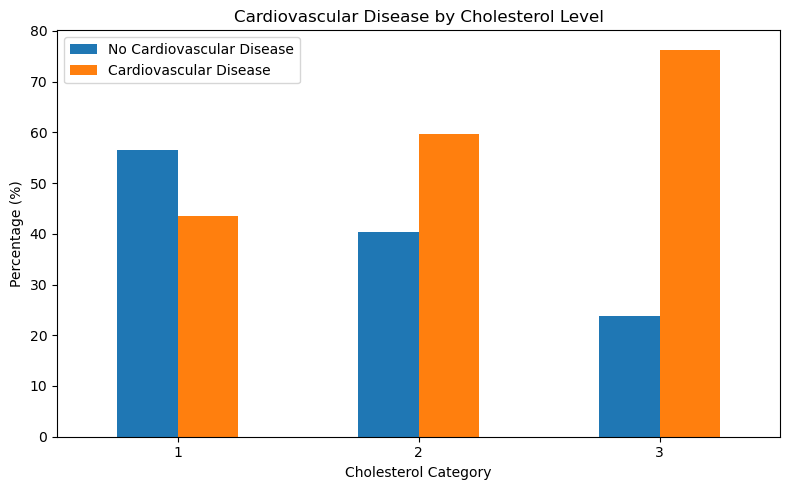

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

chol_cardio_plot = pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
) * 100

chol_cardio_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Cardiovascular Disease by Cholesterol Level")
plt.xlabel("Cholesterol Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["No Cardiovascular Disease", "Cardiovascular Disease"])
plt.tight_layout()
plt.show()

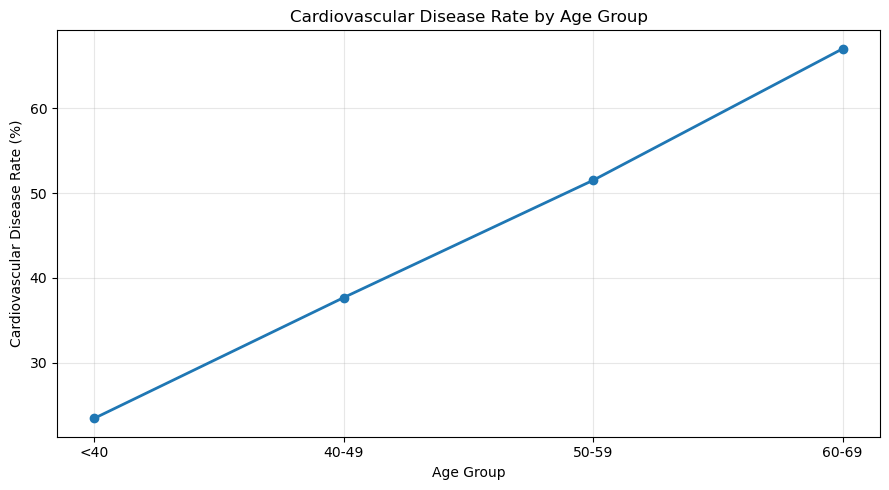

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

age_cardio_plot = pd.crosstab(
    df["age_group"],
    df["cardio"],
    normalize="index"
) * 100

age_cardio_rate = age_cardio_plot[1]

plt.figure(figsize=(9, 5))

plt.plot(
    age_cardio_rate.index.astype(str),
    age_cardio_rate.values,
    marker="o",
    linewidth=2
)

plt.title("Cardiovascular Disease Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Cardiovascular Disease Rate (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

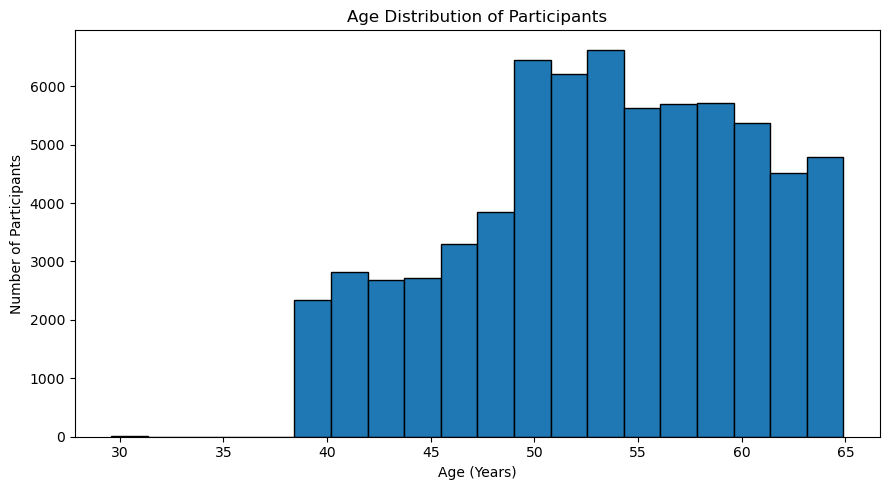

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    df["age_years"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution of Participants")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

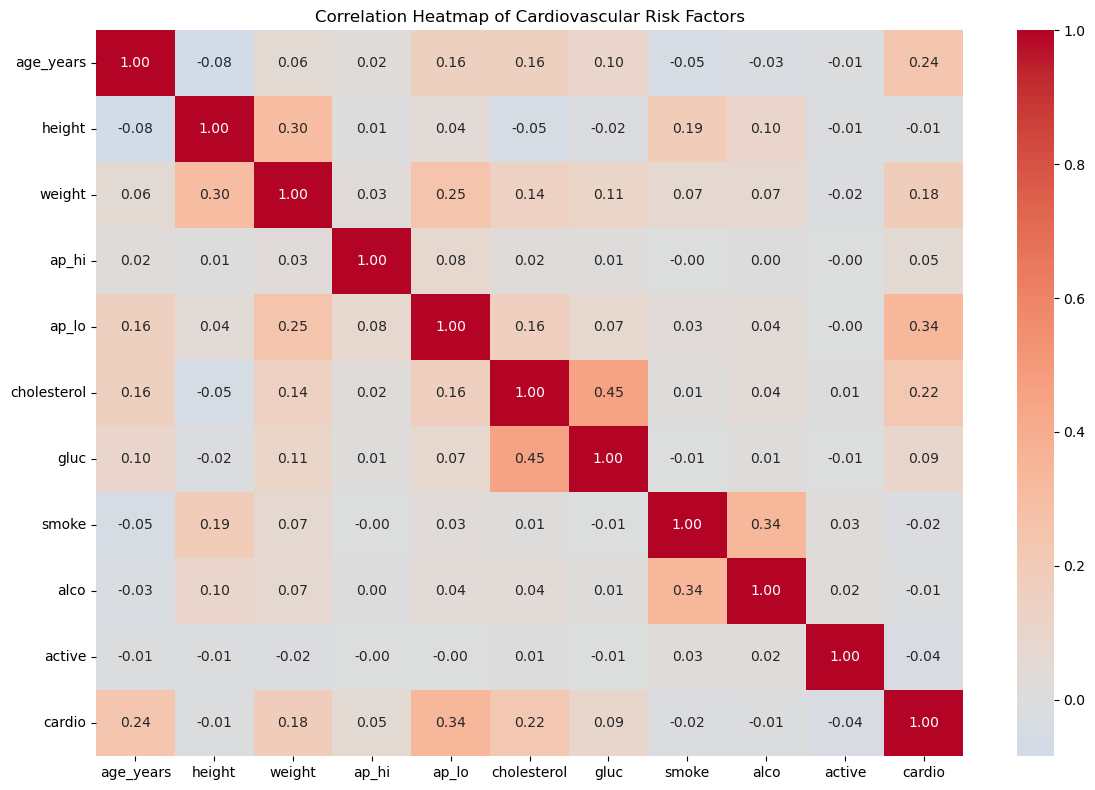

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_columns = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "cardio"
]

corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Cardiovascular Risk Factors")

plt.tight_layout()
plt.show()

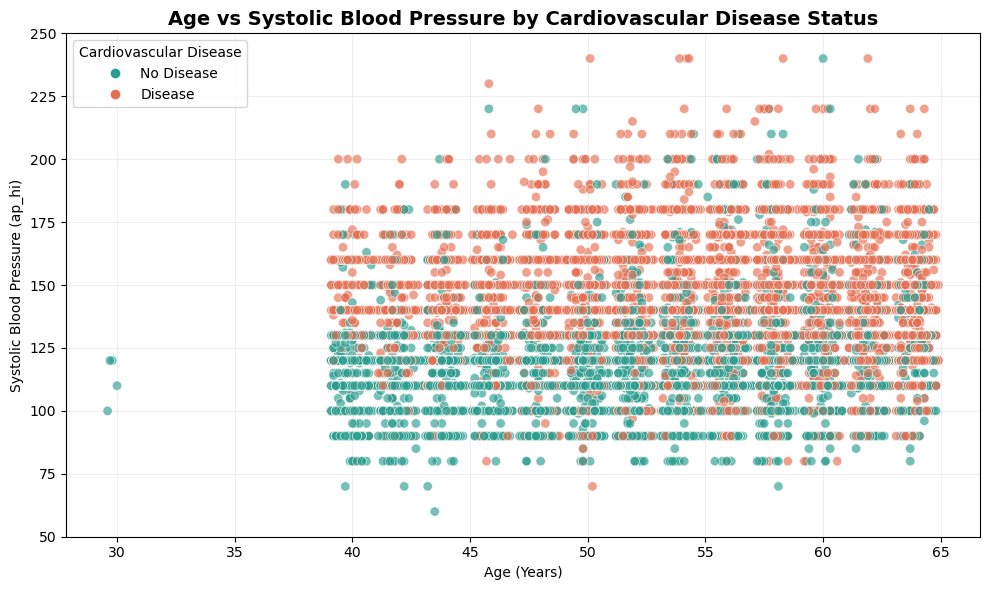

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=df,
    x="age_years",
    y="ap_hi",
    hue="cardio",
    hue_order=[0, 1],
    palette={
        0: "#2A9D8F",   # Teal = No Disease
        1: "#E76F51"    # Coral = Disease
    },
    alpha=0.65,
    s=45,
    legend=False
)

plt.title(
    "Age vs Systolic Blood Pressure by Cardiovascular Disease Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age (Years)")
plt.ylabel("Systolic Blood Pressure (ap_hi)")

plt.ylim(50, 250)

# Create correct legend manually
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#2A9D8F",
        markersize=8,
        label="No Disease"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#E76F51",
        markersize=8,
        label="Disease"
    )
]

plt.legend(
    handles=legend_handles,
    title="Cardiovascular Disease"
)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [68]:
print("Final Dataset Shape:", df.shape)
print("\nCardiovascular Disease Distribution:")
print(df["cardio"].value_counts())

print("\nCardiovascular Disease Percentage:")
print(df["cardio"].value_counts(normalize=True) * 100)

print("\nAverage Values by Cardiovascular Disease Status:")
print(
    df.groupby("cardio")[[
        "age_years",
        "height",
        "weight",
        "ap_hi",
        "ap_lo"
    ]].mean().round(2)
)

Final Dataset Shape: (68711, 15)

Cardiovascular Disease Distribution:
cardio
0    34709
1    34002
Name: count, dtype: int64

Cardiovascular Disease Percentage:
cardio
0    50.514474
1    49.485526
Name: proportion, dtype: float64

Average Values by Cardiovascular Disease Status:
        age_years  height  weight   ap_hi  ap_lo
cardio                                          
0           51.69  164.49   71.57  120.56  78.09
1           54.92  164.30   76.72  137.17  84.52


In [69]:
cholesterol_analysis = pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
) * 100

print("Cardiovascular Disease Percentage by Cholesterol Category:")
print(cholesterol_analysis.round(2))

Cardiovascular Disease Percentage by Cholesterol Category:
cardio           0      1
cholesterol              
1            56.44  43.56
2            40.37  59.63
3            23.72  76.28


Higher cholesterol categories were associated with a higher proportion of cardiovascular disease cases in the dataset. The disease proportion increased from 43.56% in category 1 to 76.28% in category 3. This represents an observed association and does not establish causation.

In [70]:
age_analysis = df.groupby("cardio")["age_years"].mean()

print("Average Age by Cardiovascular Disease Status:")
print(age_analysis.round(2))

Average Age by Cardiovascular Disease Status:
cardio
0    51.69
1    54.92
Name: age_years, dtype: float64


Participants with cardiovascular disease had a higher average age than participants without cardiovascular disease. The average age was approximately 51.69 years for the no-disease group and 54.92 years for the disease group.

In [71]:
bp_analysis = df.groupby("cardio")[["ap_hi", "ap_lo"]].mean()

print("Average Blood Pressure by Cardiovascular Disease Status:")
print(bp_analysis.round(2))

Average Blood Pressure by Cardiovascular Disease Status:
         ap_hi  ap_lo
cardio               
0       120.56  78.09
1       137.17  84.52


The cardiovascular disease group had higher average systolic and diastolic blood pressure than the no-disease group. Mean systolic blood pressure was 137.17 compared with 120.56, while mean diastolic blood pressure was 84.52 compared with 78.09.